# Marketing A/B Testing Analysis

### Business Question
Does exposure to the marketing advertisement increase conversion compared with the control group?

### Treatment Group
Ad

### Control Group
PSA

### Target Variable
Converted

### Key Methods
EDA | Chi-square | Shapiro-Wilk | Levene | Mann-Whitney U

###### About Dataset: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing


#### Marketing A/B testing dataset

Marketing companies want to run successful campaigns, but the market is complex and several options can work. So normally they tun A/B tests, that is a randomized experimentation process wherein two or more versions of a variable (web page, page element, banner, etc.) are shown to different segments of people at the same time to determine which version leaves the maximum impact and drive business metrics.

The companies are interested in answering two questions:

Would the campaign be successful?
If the campaign was successful, how much of that success could be attributed to the ads?
With the second question in mind, we normally do an A/B test. 

#### The majority of the people will be exposed to ads (the experimental group). And a small portion of people (the control group) would instead see a Public Service Announcement (PSA) (or nothing) in the exact size and place the ad would normally be.

The idea of the dataset is to analyze the groups, find if the ads were successful, how much the company can make from the ads, and if the difference between the groups is statistically significant.

Data dictionary:

- Index: Row index

- user id: User ID (unique)
- test group: If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
- converted: If a person bought the product then True, else is False
- total ads: Amount of ads seen by person
- most ads day: Day that the person saw the biggest amount of ads
- most ads hour: Hour of day that the person saw the biggest amount of ads

In [3]:
# Importing basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Reading the dataset

df = pd.read_csv("marketing_AB.csv")

In [5]:
# Checking the observations

df.shape

(588101, 7)

In [6]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [7]:
# Checking if we have duplicates with respect to user id

df.duplicated(subset = 'user id').sum()

0

In [8]:
# dropping unwanted columns

df.drop(['Unnamed: 0', 'user id'], axis = 1, inplace = True)

In [9]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [10]:
# checking if the categorical variables have appropriate number of levels

df_cat = df[['test group', 'converted','most ads day',
       'most ads hour']]

df_cat.nunique()


# test group        2 (ab or pca)
# converted         2 (true or false)
# most ads day      7 (7 days of the week)
# most ads hour    24 (24 hr format)

test group        2
converted         2
most ads day      7
most ads hour    24
dtype: int64

In [11]:
# checking if the categorical variables have appropriate levels

for i in df_cat.columns:
    print(i.upper(), ":", df_cat[i].unique())

TEST GROUP : ['ad' 'psa']
CONVERTED : [False  True]
MOST ADS DAY : ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
MOST ADS HOUR : [20 22 18 10 14 13 19 11 12 16 21  3 23  4  8  0  2 15  1  6 17  7  9  5]


## Univariate analysis

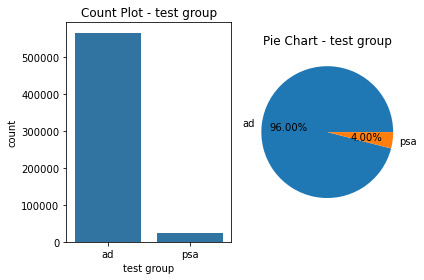

In [12]:
variable = 'test group'

plt.figure(figsize = (6,4))

# Count plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data = df_cat)
plt.title(f'Count Plot - {variable}')

# Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct = '%0.2f%%')
plt.title(f"Pie Chart - {variable}")


# Adjust the layout
plt.tight_layout()


# Show the plots
plt.show()

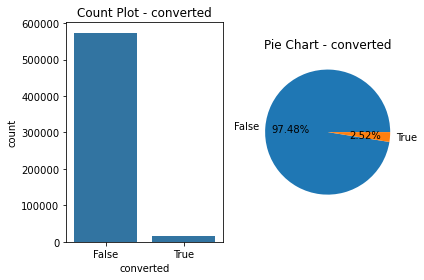

In [13]:
variable = 'converted'

plt.figure(figsize = (6,4))

# Count plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data = df_cat)
plt.title(f'Count Plot - {variable}')

# Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct = '%0.2f%%')
plt.title(f"Pie Chart - {variable}")


# Adjust the layout
plt.tight_layout()


# Show the plots
plt.show()

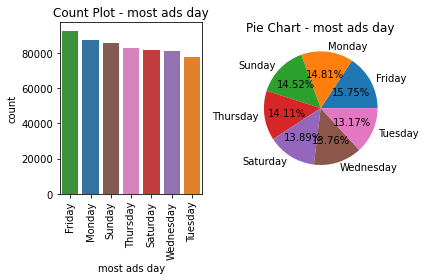

In [14]:
variable = 'most ads day'

plt.figure(figsize = (6,4))

# Count plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data = df_cat, order = df_cat['most ads day'].value_counts().index, hue = 'most ads day')
plt.title(f'Count Plot - {variable}')
plt.xticks(rotation = 90)



# Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct = '%0.2f%%')
plt.title(f"Pie Chart - {variable}")


# Adjust the layout
plt.tight_layout()


# Show the plots
plt.show()

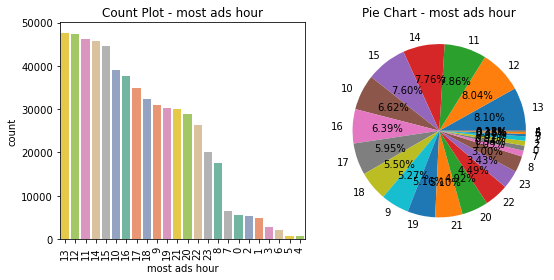

In [15]:
variable = 'most ads hour'

plt.figure(figsize = (8,4))

# Count plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data = df_cat, order = df_cat['most ads hour'].value_counts().index, hue = variable,  
              palette='Set2', legend=False)
plt.title(f'Count Plot - {variable}')
plt.xticks(rotation = 90)



# Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct = '%0.2f%%')
plt.title(f"Pie Chart - {variable}")


# Adjust the layout
plt.tight_layout()


# Show the plots
plt.show()

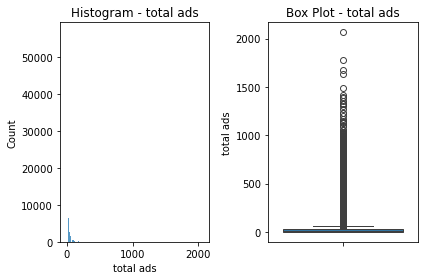

In [16]:
variable = 'total ads'

plt.figure(figsize = (6,4))

# Histogram
plt.subplot(1,2,1)
sns.histplot(x=variable, data = df)
plt.title(f'Histogram - {variable}')


# Pie Chart
plt.subplot(1,2,2)
sns.boxplot(y = variable, data = df)
plt.title(f"Box Plot - {variable}")


# Adjust the layout
plt.tight_layout()


# Show the plots
plt.show()

In [17]:
# Checking the Descriptive Statistics of this feature
df['total ads'].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

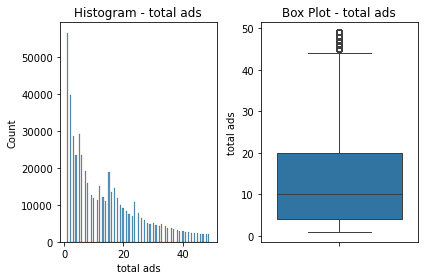

In [18]:
variable = 'total ads'

plt.figure(figsize = (6,4))

# Histogram
plt.subplot(1,2,1)

# Filtering the data for a value close to 75th percentile only for better visualisation
sns.histplot(x=variable, data = df[df['total ads'] < 50])
plt.title(f'Histogram - {variable}')


# Pie Chart
plt.subplot(1,2,2)
sns.boxplot(y = variable, data = df[df['total ads'] < 50])
plt.title(f"Box Plot - {variable}")


# Adjust the layout
plt.tight_layout()


# Show the plots
plt.show()

## Bivariate analysis

- How does each variable relate to conversion?

In [19]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [20]:
ct_conversion_test_group = pd.crosstab(df['test group'], df['converted'], normalize = 'index')
ct_conversion_test_group

# normalize = 'index' - - Pandas calculates percentages within each row.

# out of the total people who have seen the 'ad', only 2.55 % people have purchased/converted
# out of the total people who have seen the 'ad', only 1.78 % people have purchased/converted

converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


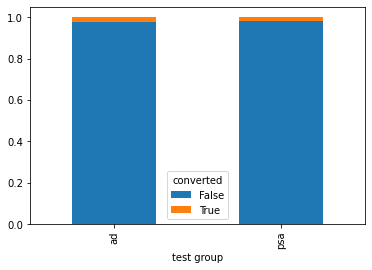

In [21]:
ct_conversion_test_group.plot.bar(stacked = True);

### Does the day on which the user saw the most advertisements relate to conversion?

converted        False      True
most ads day                    
Monday        0.967188  0.032812
Tuesday       0.970160  0.029840
Wednesday     0.975058  0.024942
Sunday        0.975524  0.024476
Friday        0.977788  0.022212
Thursday      0.978429  0.021571
Saturday      0.978949  0.021051


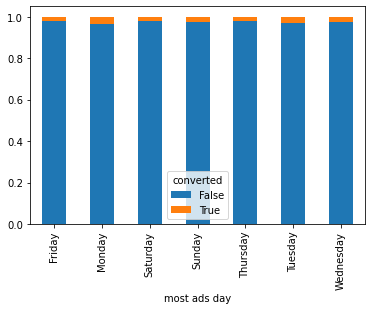

In [22]:
ct_conversion_day = pd.crosstab(df['most ads day'], df['converted'], normalize = 'index')
print(ct_conversion_day.sort_values(by = True, ascending = False))
ct_conversion_day.plot.bar(stacked = True);

### "At which hour were the most ads displayed?"

converted         False      True
most ads hour                    
16             0.969228  0.030772
20             0.970197  0.029803
15             0.970347  0.029653
21             0.971077  0.028923
17             0.971790  0.028210
14             0.971937  0.028063
18             0.972620  0.027380
19             0.973280  0.026720
22             0.973895  0.026105
13             0.975323  0.024677
12             0.976172  0.023828
23             0.977338  0.022662
6              0.977756  0.022244
11             0.977884  0.022116
10             0.978479  0.021521
5              0.979085  0.020915
8              0.980484  0.019516
9              0.980809  0.019191
0              0.981575  0.018425
7              0.981889  0.018111
4              0.984765  0.015235
1              0.987089  0.012911
3              0.989548  0.010452
2              0.992687  0.007313


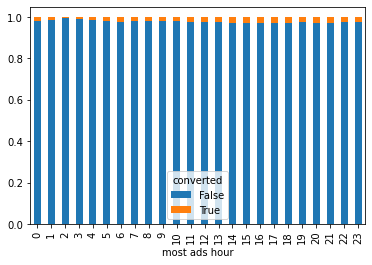

In [23]:
ct_conversion_hour = pd.crosstab(df['most ads hour'], df['converted'], normalize = 'index')
print(ct_conversion_hour.sort_values(by = True, ascending = False))
ct_conversion_hour.plot.bar(stacked = True);

### How does the number of ads seen differ between people who converted and people who didn't?

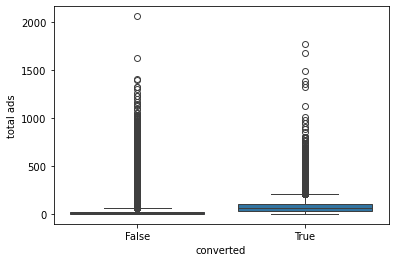

In [24]:
sns.boxplot(x = 'converted', y = 'total ads', data = df);

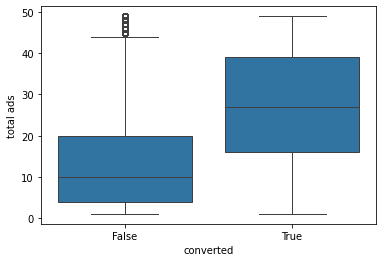

In [25]:
sns.boxplot(x = 'converted', y = 'total ads', data = df[df['total ads'] < 50]);

## Statisticsl Tests


We are now moving from:

"The chart looks different."

to:

"The difference is statistically significant."

In [26]:
# df.head()

In [27]:
df_cat

,test group,converted,most ads day,most ads hour
0,ad,False,Monday,20
1,ad,False,Tuesday,22
2,ad,False,Tuesday,18
3,ad,False,Tuesday,10
4,ad,False,Friday,14
...,...,...,...,...
588096,ad,False,Tuesday,23
588097,ad,False,Tuesday,23
588098,ad,False,Tuesday,23
588099,ad,False,Tuesday,23


In [28]:
from scipy.stats import chi2_contingency
alpha = 0.5 # alpha is the significance threshold

for variable in df_cat.columns:
    if variable != 'converted':
        # Create a contingency table (cross=tabulation)
        contingency_table = pd.crosstab(df_cat[variable], df_cat['converted'])
        
        # Perform chi-squared test
        chi2, p, _, _ = chi2_contingency(contingency_table)
        # statistic, p-value, degrees of freedom, expected frequencies
        
        # Display the results
        print(f"\nChi-squared test for {variable} vs. converted.")
        print(f"Chi-squared value: {chi2}")
        print(f"p-value: {p}")
        
        # Check for significance # Hypthesis testing
        if p < alpha:
            print(f"The difference in conversion rates across {variable} is statistically significant.")
        else:
            print(f"The is no signigicant difference in conversion rates across {variable}.")


Chi-squared test for test group vs. converted.
Chi-squared value: 54.005823883685245
p-value: 1.9989623063390075e-13
The difference in conversion rates across test group is statistically significant.

Chi-squared test for most ads day vs. converted.
Chi-squared value: 410.0478857936585
p-value: 1.932184379244731e-85
The difference in conversion rates across most ads day is statistically significant.

Chi-squared test for most ads hour vs. converted.
Chi-squared value: 430.76869230822086
p-value: 8.027629823696771e-77
The difference in conversion rates across most ads hour is statistically significant.


In [29]:
df_cat.columns

Index(['test group', 'converted', 'most ads day', 'most ads hour'], dtype='object')

In [30]:
# checking the normality of the data

from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

#  Step 1: Check Assumptions
# Normality assumption

shapiro_stat_true, shapiro_p_value_true = shapiro(df[df['converted'] == True] ['total ads'])
shapiro_stat_false, shapiro_p_value_false = shapiro(df[df['converted'] == False] ['total ads'])

print(f"Shapiro-Wilk test for normality (True group): p-value = {shapiro_p_value_true}")
print(f"Shapiro-Wilk test for normality (False group): p-value = {shapiro_p_value_false}")


# Equality of variances assumption
levene_stat, levene_p_value = levene(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
print(f"Levene's test for equality of variances: p-value = {levene_p_value}")


Shapiro-Wilk test for normality (True group): p-value = 1.638680987007771e-98
Shapiro-Wilk test for normality (False group): p-value = 9.883049430735801e-204
Levene's test for equality of variances: p-value = 0.0


In [31]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [32]:
# Step 2: Perform a Suitable Test

alpha = 0.05

if shapiro_p_value_true > alpha and shapiro_p_value_false > alpha and levene_p_value > alpha:
    # Assumptions met - use t-test for means
    t_stat, t_p_value = ttest_ind(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
    print(f"Independent two-sample t-test: p-value = {t_p_value}")
else:
    # Assunptionss not met - use Mann-Whitney U test for medians
    u_stat, u_p_value = mannwhitneyu(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
    print(f"Mann-Whitney U test: p-value = {u_p_value}")

Mann-Whitney U test: p-value = 0.0
